<a href="https://colab.research.google.com/github/yuningrumzattayu/Pengembangan-Machine-Learning/blob/main/Analisis_Sentiment_menggunakan_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
seed = 0
np.random.seed(seed)
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import requests
from io import StringIO
from sklearn.model_selection import train_test_split

In [ ]:
clean_df = pd.read_csv('data_cleaned.csv')

In [ ]:
clean_df = clean_df.dropna()
print("Jumlah Ulasan", clean_df.shape[0])

Jumlah Ulasan 11992


### Pelabelan

In [ ]:
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')

if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')

    for row in reader:
        lexicon_positive[row[0]] = int(row[1])

else:
    print("Failed to fetch positive lexicon data")

lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')

if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')

    for row in reader:
        lexicon_negative[row[0]] = int(row[1])
else:
    print("Failed to fetch negative lexicon data")

In [ ]:
def sentiment_analysis_lexicon_indonesia(text):
    score = 0
    for word in text.split():
        if (word in lexicon_positive):
            score = score + lexicon_positive[word]

    for word in text.split():
        if (word in lexicon_negative):
            score = score + lexicon_negative[word]

    polarity=''

    if (score > 0):
        polarity = 'positive'
    elif (score < 0):
        polarity = 'negative'
    else:
        polarity = 'neutral'

    return score, polarity

In [ ]:
results = clean_df['text_akhir'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
negative    8297
positive    3101
neutral      594
Name: count, dtype: int64


polarity
negative    8297
positive    3101
neutral      594
Name: count, dtype: int64


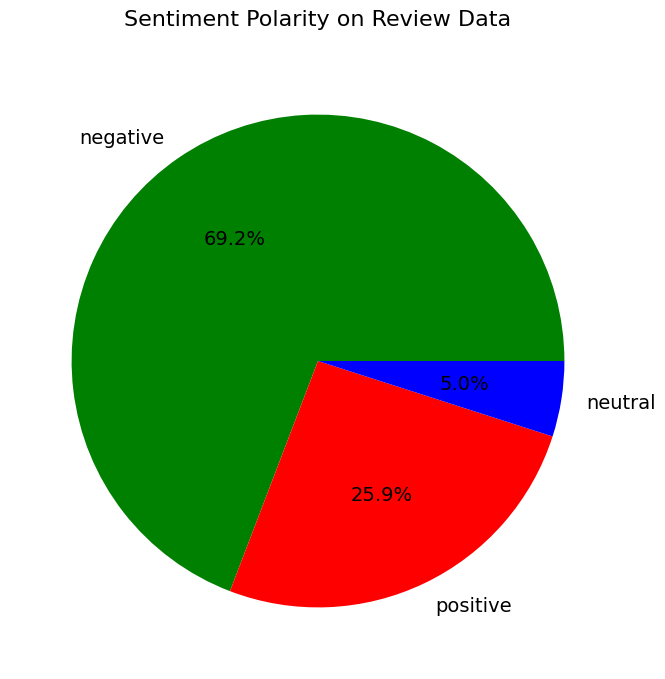

In [ ]:
import matplotlib.pyplot as plt

results = clean_df['text_akhir'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]

print(clean_df['polarity'].value_counts())

fig, ax = plt.subplots(figsize=(8, 8))

sizes = clean_df['polarity'].value_counts().values
labels = clean_df['polarity'].value_counts().index
colors = ['green', 'red', 'blue']

ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', colors=colors, textprops={'fontsize': 14})

ax.set_title('Sentiment Polarity on Review Data', fontsize=16, pad=20)

plt.show()

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score, precision_score

### Data Splitting

In [ ]:
clean_df.head(2)

,reviews,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,polarity_score,polarity
0,"Barusan saya beli paket data, ketika mau saya ...",Barusan saya beli paket data ketika mau saya s...,barusan saya beli paket data ketika mau saya s...,barusan saya beli paket data ketika mau saya s...,"['barusan', 'saya', 'beli', 'paket', 'data', '...","['barusan', 'beli', 'paket', 'data', 'scan', '...",barusan beli paket data scan diisi apk myxl ke...,-1,negative
1,"Aplikasi sangat jelek, mengecewakan, sdh uppda...",Aplikasi sangat jelek mengecewakan sdh uppdate...,aplikasi sangat jelek mengecewakan sdh uppdate...,aplikasi sangat jelek mengecewakan sdh uppdate...,"['aplikasi', 'sangat', 'jelek', 'mengecewakan'...","['aplikasi', 'jelek', 'mengecewakan', 'sdh', '...",aplikasi jelek mengecewakan sdh uppdate aktifk...,-15,negative


In [ ]:
# Pisahkan data menjadi fitur (tweet) dan label (sentimen)
X = clean_df['text_akhir']
y = clean_df['polarity']

In [ ]:
# Ekstraksi fitur dengan TF-IDF
tfidf = TfidfVectorizer(max_features=200, min_df=17, max_df=0.8 )
X_tfidf = tfidf.fit_transform(X)

In [ ]:
# Konversi hasil ekstraksi fitur menjadi dataframe
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Menampilkan hasil ekstraksi fitur
features_df

,akses,aktif,akun,ambil,aneh,apk,apknya,aplikasi,aplikasinya,app,...,uang,udh,ulang,update,utama,versi,voucher,wifi,xl,youtube
0,0.000000,0.0,0.0,0.0,0.0,0.573789,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.267407,0.0,0.0,0.0,0.0,0.000000,0.0
1,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.325908,0.000000,0.0,...,0.0,0.0,0.000000,0.114181,0.0,0.0,0.0,0.0,0.076974,0.0
2,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
3,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.098556,0.316161,0.0,...,0.0,0.0,0.191294,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
4,0.431625,0.0,0.0,0.0,0.0,0.265212,0.0,0.088197,0.000000,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11987,0.000000,0.0,0.0,0.0,0.0,0.395324,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
11988,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.071349,0.0
11989,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.206349,0.000000,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.389887,0.0
11990,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.272919,0.0,0.0,0.0,0.0,0.000000,0.0


In [ ]:
# Skenario 1: 70:30
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(X_tfidf, y, test_size=0.3, random_state=42)
print(f"70:30 - Ukuran data latih: {X_train_70.shape[0]}, Ukuran data uji: {X_test_30.shape[0]}")

# Skenario 2: 80:20
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)
print(f"80:20 - Ukuran data latih: {X_train_80.shape[0]}, Ukuran data uji: {X_test_20.shape[0]}")

# Skenario 3: 90:10
X_train_90, X_test_10, y_train_90, y_test_10 = train_test_split(X_tfidf, y, test_size=0.1, random_state=42)
print(f"90:10 - Ukuran data latih: {X_train_90.shape[0]}, Ukuran data uji: {X_test_10.shape[0]}")

70:30 - Ukuran data latih: 8394, Ukuran data uji: 3598
80:20 - Ukuran data latih: 9593, Ukuran data uji: 2399
90:10 - Ukuran data latih: 10792, Ukuran data uji: 1200


### Pemodelan Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Fungsi untuk melatih dan mengevaluasi model Logistic Regression
def train_and_evaluate_lr(X_train, X_test, y_train, y_test, title):
    # Membuat objek model Logistic Regression
    logistic_regression = LogisticRegression()

    # Melatih model Logistic Regression pada data pelatihan
    logistic_regression.fit(X_train.toarray(), y_train)

    # Prediksi sentimen pada data uji
    y_pred_test = logistic_regression.predict(X_test.toarray())

    # Prediksi sentimen pada data latih
    y_pred_train = logistic_regression.predict(X_train.toarray())

    # Evaluasi akurasi model Logistic Regression pada data latih dan data uji
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)

    # Menampilkan akurasi
    print(f'{title} - accuracy_train:', accuracy_train)
    print(f'{title} - accuracy_test:', accuracy_test)

    return y_pred_train, y_pred_test

# Skenario 2: 70:30
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(X_tfidf, y, test_size=0.3, random_state=42)
y_pred_train_70, y_pred_test_30 = train_and_evaluate_lr(X_train_70, X_test_30, y_train_70, y_test_30, "Skenario 70:30")

# Skenario 3: 80:20
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)
y_pred_train_80, y_pred_test_20 = train_and_evaluate_lr(X_train_80, X_test_20, y_train_80, y_test_20, "Skenario 80:20")

# Skenario 4: 90:10
X_train_90, X_test_10, y_train_90, y_test_10 = train_test_split(X_tfidf, y, test_size=0.1, random_state=42)
y_pred_train_90, y_pred_test_10 = train_and_evaluate_lr(X_train_90, X_test_10, y_train_90, y_test_10, "Skenario 90:10")

Skenario 70:30 - accuracy_train: 0.8620443173695497
Skenario 70:30 - accuracy_test: 0.8501945525291829
Skenario 80:20 - accuracy_train: 0.861982695715626
Skenario 80:20 - accuracy_test: 0.8536890370987912
Skenario 90:10 - accuracy_train: 0.8622127501853225
Skenario 90:10 - accuracy_test: 0.8516666666666667


In [ ]:
pip freeze > requirements.txt